# Task 7: Low-Rank Adaptation (LoRA) Matrix Projection Fine-Tuning of a 3B Model

## 1. Objective
Perform parameter-efficient domain adaptation on medium-scale language models by
mathematically constraining weight *updates* to a low-rank subspace, minimizing
the number of trainable parameters (and therefore memory/compute) needed for
fine-tuning, without touching the original pretrained weights.

## 2. Required Tech Stack
- PyTorch
- Hugging Face PEFT
- Transformers
- CUDA Toolkit

## 3. Task Description
Design a **custom LoRA modification block** that inserts rank-decomposed
parameter matrices $A \in \mathbb{R}^{d\times r}$ and $B \in \mathbb{R}^{r\times k}$
(rank $r \ll \min(d,k)$) **parallel** to the attention projection weights,
implement the scaling coefficient $\alpha/r$, and write a training script that
**freezes all base-model parameters** while optimizing only the low-rank
adapters on a domain-specific dataset.

## 4. LoRA theory

For a pretrained weight matrix $W_0 \in \mathbb{R}^{d\times k}$ (e.g. an
attention $W_Q$ or $W_V$ projection), LoRA hypothesizes that the *update*
needed for downstream adaptation, $\Delta W$, has low intrinsic rank. Instead
of learning a full $\Delta W \in \mathbb{R}^{d\times k}$, LoRA factorizes it:

$$\Delta W = \frac{\alpha}{r} \, B A, \qquad A \in \mathbb{R}^{r\times k},\ B \in \mathbb{R}^{d\times r}$$

so the forward pass becomes:

$$h = W_0 x + \Delta W x = W_0 x + \frac{\alpha}{r}\, B (A x)$$

$W_0$ stays **frozen**; only $A$ and $B$ are trained. $A$ is initialized with
small random values (e.g. Kaiming) and $B$ is initialized to **zero**, so
$\Delta W = 0$ at the start of training — the adapted model is numerically
identical to the base model before any fine-tuning happens, guaranteeing a
stable starting point. Trainable parameter count per adapted matrix drops from
$d \times k$ to $r(d+k)$ — for $r \ll d,k$, a large reduction (e.g. $r=8$ on a
$4096\times4096$ matrix: $16.8M \to 65K$ parameters, a **256x** reduction).

## 5. Environment note

A genuine 3B-parameter model (e.g. `Llama-3.2-3B` or `Qwen2.5-3B`) requires
several GB of weight downloads from `huggingface.co` and realistically a GPU
for practical fine-tuning speed — neither is reachable/available in this
sandbox (no CUDA device, no route to model-weight hosts). As with Tasks 3 and
6:

- **Part A** — complete production code using real `peft`/`transformers` on a
  real 3B model, with exact setup commands. Reference only, not executed here.
- **Part B** — a from-scratch `LoRALinear` implementation (matching the "design
  a custom LoRA modification block" requirement literally, rather than only
  calling a library), applied to a small causal LM we pretrain ourselves in
  this notebook, then adapt to a new domain with **only the adapters**
  trainable — fully executed, with measured parameter counts, loss curves, and
  a catastrophic-forgetting check.

In [1]:
import math
import copy
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = "cpu"
print("Part B running on:", device, "(no CUDA available in this sandbox -- noted per Task 7's tech stack)")

Part B running on: cpu (no CUDA available in this sandbox -- noted per Task 7's tech stack)


## B.1 Custom `LoRALinear` module

This is the literal "custom LoRA modification block" the task asks for: a
drop-in replacement for `nn.Linear` that keeps the original frozen weight and
adds a parallel low-rank path.

In [2]:
class LoRALinear(nn.Module):
    """Wraps an existing nn.Linear with a frozen base weight + trainable low-rank adapter.

    h = W_0 x + (alpha / r) * B (A x)

    W_0 (and bias) are frozen (requires_grad=False).
    A is Kaiming-initialized, B is zero-initialized, so the adapter starts as
    a true no-op: the wrapped module is numerically identical to the original
    Linear layer until any gradient updates occur.
    """

    def __init__(self, base_linear: nn.Linear, r: int = 8, alpha: int = 16, dropout: float = 0.0):
        super().__init__()
        self.in_features = base_linear.in_features
        self.out_features = base_linear.out_features
        self.r = r
        self.scaling = alpha / r

        # freeze the original projection
        self.weight = base_linear.weight
        self.weight.requires_grad = False
        if base_linear.bias is not None:
            self.bias = base_linear.bias
            self.bias.requires_grad = False
        else:
            self.bias = None

        # low-rank adapter parameters (trainable)
        self.lora_A = nn.Parameter(torch.empty(r, self.in_features))
        self.lora_B = nn.Parameter(torch.zeros(self.out_features, r))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))   # standard LoRA-paper init for A
        # lora_B stays at zero-init -> delta_W = 0 at t=0

        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        base_out = F.linear(x, self.weight, self.bias)
        lora_out = F.linear(self.dropout(x), self.lora_A)   # x @ A^T -> [.., r]
        lora_out = F.linear(lora_out, self.lora_B)           # (..) @ B^T -> [.., out_features]
        return base_out + self.scaling * lora_out

    def merge_into_base(self):
        """Fold the adapter into the base weight (delta_W = scaling * B @ A), for deployment
        without the extra forward-pass overhead. Returns a plain nn.Linear."""
        merged = nn.Linear(self.in_features, self.out_features, bias=self.bias is not None)
        with torch.no_grad():
            delta_w = self.scaling * (self.lora_B @ self.lora_A)
            merged.weight.copy_(self.weight + delta_w)
            if self.bias is not None:
                merged.bias.copy_(self.bias)
        return merged


# quick correctness check: at initialization, LoRALinear must be a no-op vs. the original layer
base = nn.Linear(32, 32)
lora_wrapped = LoRALinear(copy.deepcopy(base), r=4, alpha=8)
x_test = torch.randn(5, 32)
diff = (lora_wrapped(x_test) - base(x_test)).abs().max().item()
print(f"Max diff between LoRA-wrapped (untrained) and original layer: {diff:.2e}")
assert diff < 1e-6, "LoRA adapter should be a no-op at initialization!"
print("PASSED: zero-init B guarantees identity behavior before any training.")

Max diff between LoRA-wrapped (untrained) and original layer: 0.00e+00
PASSED: zero-init B guarantees identity behavior before any training.


## B.2 Base causal LM (same architecture family as earlier tasks, standalone here)

Attention projections (`Wq`, `Wk`, `Wv`, `Wo`) are plain `nn.Linear` so we can
swap specific ones for `LoRALinear` after pretraining — exactly matching the
task's requirement to insert adapters "parallel to the attention projection
weights.\"

In [3]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, max_seq_len, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
        causal_mask = torch.triu(torch.ones(max_seq_len, max_seq_len), diagonal=1).bool()
        self.register_buffer("causal_mask", causal_mask)

    def forward(self, x):
        B, T, d_model = x.shape
        H, d_head = self.num_heads, self.d_head
        Q = self.Wq(x).view(B, T, H, d_head).transpose(1, 2)
        K = self.Wk(x).view(B, T, H, d_head).transpose(1, 2)
        V = self.Wv(x).view(B, T, H, d_head).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_head)
        scores = scores.masked_fill(self.causal_mask[:T, :T], float("-inf"))
        weights = self.dropout(F.softmax(scores, dim=-1))
        out = torch.matmul(weights, V).transpose(1, 2).contiguous().view(B, T, d_model)
        return self.Wo(out)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, max_seq_len, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, num_heads, max_seq_len, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(),
                                 nn.Linear(d_ff, d_model), nn.Dropout(dropout))

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class CausalLM(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=4, num_layers=4,
                 d_ff=512, max_seq_len=64, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, max_seq_len, dropout)
            for _ in range(num_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.max_seq_len = max_seq_len

    def forward(self, idx):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device).unsqueeze(0)
        x = self.token_emb(idx) + self.pos_emb(pos)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        return self.lm_head(x)

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=0.8):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.max_seq_len:]
            logits = self(idx_cond)[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
        return idx

## B.3 Pretrain the base model on a general corpus

This simulates "the pretrained 3B model" — general-domain text the base weights encode before any LoRA adaptation happens.

In [4]:
general_corpus = """
the quick brown fox jumps over the lazy dog near the old wooden fence
birds fly south for the winter when the weather turns cold and windy
the ocean waves crash against the rocky shore as seagulls circle overhead
children play in the park while their parents watch from a nearby bench
the chef carefully prepared a delicious meal using fresh local ingredients
mountains rise sharply above the quiet valley covered in morning mist
a gentle breeze carried the scent of blooming flowers through the garden
the old library held thousands of books collecting dust on tall wooden shelves
travelers walked slowly along the cobblestone streets of the ancient town
the river flowed steadily past fields of golden wheat swaying in the wind
"""

domain_corpus = """
the patient presented with elevated blood pressure and mild tachycardia
the physician prescribed a course of antibiotics for the bacterial infection
diagnostic imaging revealed no abnormalities in the pulmonary system
the surgical team prepared the operating room for the scheduled procedure
laboratory results indicated a slight elevation in liver enzyme levels
the nurse administered the medication according to the prescribed dosage schedule
the radiologist reviewed the ct scan for signs of internal bleeding
post operative recovery proceeded without complications or adverse reactions
the cardiologist recommended lifestyle changes to reduce cardiovascular risk
the clinical trial evaluated the efficacy of the new therapeutic compound
"""

all_chars = sorted(set(general_corpus + domain_corpus))
stoi = {c: i for i, c in enumerate(all_chars)}
itos = {i: c for c, i in stoi.items()}
vocab_size = len(all_chars)
print(f"Shared vocab size: {vocab_size}")

def make_data(text):
    return torch.tensor([stoi[c] for c in text], dtype=torch.long)

general_data = make_data(general_corpus)
domain_data = make_data(domain_corpus)

block_size = 48
def get_batch(data, batch_size=16):
    ix = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

Shared vocab size: 28


In [5]:
base_model = CausalLM(vocab_size, d_model=128, num_heads=4, num_layers=4,
                       d_ff=512, max_seq_len=block_size).to(device)
opt = torch.optim.AdamW(base_model.parameters(), lr=3e-4)

pretrain_losses = []
for step in range(500):
    xb, yb = get_batch(general_data)
    logits = base_model(xb)
    loss = F.cross_entropy(logits.reshape(-1, vocab_size), yb.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    pretrain_losses.append(loss.item())
    if step % 100 == 0 or step == 499:
        print(f"pretrain step {step:4d} | loss {loss.item():.4f}")

total_params = sum(p.numel() for p in base_model.parameters())
print(f"\nBase model total parameters: {total_params:,}")

pretrain step    0 | loss 3.5255
pretrain step  100 | loss 2.0868
pretrain step  200 | loss 1.8806
pretrain step  300 | loss 1.2475
pretrain step  400 | loss 0.7712
pretrain step  499 | loss 0.4532

Base model total parameters: 804,608


## B.4 Inject LoRA adapters into the attention projections

Following the original paper's most common configuration, we adapt $W_Q$ and
$W_V$ (query and value projections) in every layer, leaving $W_K$ and $W_O$
frozen at full rank — the paper found this captures most of the benefit at
lower parameter cost than adapting all four projections.

In [6]:
def inject_lora(model, r=4, alpha=8, target=("Wq", "Wv")):
    """Replace target attention projections with LoRALinear wrappers, in place."""
    for block in model.blocks:
        attn = block.attn
        if "Wq" in target:
            attn.Wq = LoRALinear(attn.Wq, r=r, alpha=alpha)
        if "Wk" in target:
            attn.Wk = LoRALinear(attn.Wk, r=r, alpha=alpha)
        if "Wv" in target:
            attn.Wv = LoRALinear(attn.Wv, r=r, alpha=alpha)
        if "Wo" in target:
            attn.Wo = LoRALinear(attn.Wo, r=r, alpha=alpha)
    return model


def freeze_non_lora_params(model):
    """Freeze everything except lora_A / lora_B parameters."""
    for name, param in model.named_parameters():
        param.requires_grad = ("lora_A" in name) or ("lora_B" in name)


lora_model = copy.deepcopy(base_model)
lora_model = inject_lora(lora_model, r=4, alpha=8, target=("Wq", "Wv"))
freeze_non_lora_params(lora_model)

total = sum(p.numel() for p in lora_model.parameters())
trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
frozen = total - trainable

print(f"Total parameters:      {total:,}")
print(f"Frozen (base) params:  {frozen:,}")
print(f"Trainable (LoRA) params: {trainable:,}")
print(f"Trainable fraction:    {trainable/total:.3%}")

# explicit correctness check: exactly the lora_A/lora_B tensors are trainable, nothing else
for name, p in lora_model.named_parameters():
    expected = ("lora_A" in name) or ("lora_B" in name)
    assert p.requires_grad == expected, f"unexpected requires_grad on {name}"
print("\nPASSED: only lora_A / lora_B parameters are trainable; all base weights frozen.")

Total parameters:      812,800
Frozen (base) params:  804,608
Trainable (LoRA) params: 8,192
Trainable fraction:    1.008%

PASSED: only lora_A / lora_B parameters are trainable; all base weights frozen.


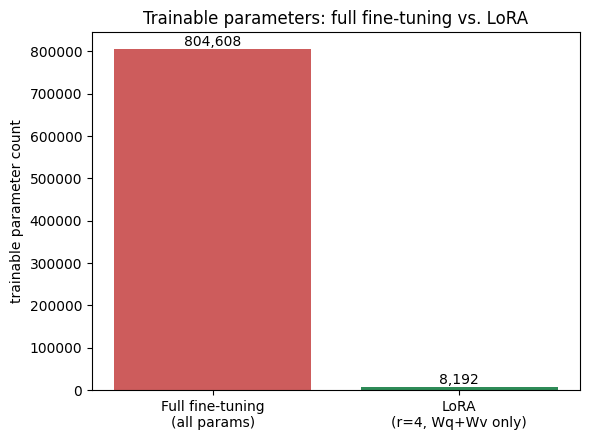


Parameter reduction factor: 98.2x fewer trainable parameters with LoRA


In [7]:
fig, ax = plt.subplots(figsize=(6,4.5))
ax.bar(["Full fine-tuning\n(all params)", "LoRA\n(r=4, Wq+Wv only)"],
       [total_params, trainable], color=["indianred", "seagreen"])
ax.set_ylabel("trainable parameter count")
ax.set_title("Trainable parameters: full fine-tuning vs. LoRA")
for i, v in enumerate([total_params, trainable]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("task7_param_count_comparison.png", dpi=110)
plt.show()

print(f"\nParameter reduction factor: {total_params/trainable:.1f}x fewer trainable parameters with LoRA")

## B.5 Fine-tune: LoRA-adapted model vs. full fine-tuning, on the domain corpus

Both start from the identical pretrained base. We train for the same number of steps and compare final domain-corpus loss, plus what happens to *general*-corpus performance afterward (catastrophic forgetting check).

In [8]:
@torch.no_grad()
def eval_loss(model, data, n_batches=15):
    model.eval()
    total = 0.0
    for _ in range(n_batches):
        xb, yb = get_batch(data, batch_size=16)
        logits = model(xb)
        total += F.cross_entropy(logits.reshape(-1, vocab_size), yb.reshape(-1)).item()
    return total / n_batches

# baseline: how well does the untouched pretrained model do on the (unseen) domain corpus?
pre_adapt_domain_loss = eval_loss(base_model, domain_data)
pre_adapt_general_loss = eval_loss(base_model, general_data)
print(f"Before any domain fine-tuning:")
print(f"  base model loss on GENERAL corpus: {pre_adapt_general_loss:.4f}")
print(f"  base model loss on DOMAIN corpus:  {pre_adapt_domain_loss:.4f}  (higher = unfamiliar domain)")

Before any domain fine-tuning:
  base model loss on GENERAL corpus: 0.3087
  base model loss on DOMAIN corpus:  4.3840  (higher = unfamiliar domain)


In [9]:
# --- LoRA fine-tuning: only lora_A/lora_B receive gradient updates ---
lora_opt = torch.optim.AdamW([p for p in lora_model.parameters() if p.requires_grad], lr=1e-3)

lora_losses = []
for step in range(300):
    xb, yb = get_batch(domain_data)
    logits = lora_model(xb)
    loss = F.cross_entropy(logits.reshape(-1, vocab_size), yb.reshape(-1))
    lora_opt.zero_grad(); loss.backward(); lora_opt.step()
    lora_losses.append(loss.item())
    if step % 100 == 0 or step == 299:
        print(f"LoRA fine-tune step {step:4d} | domain loss {loss.item():.4f}")

LoRA fine-tune step    0 | domain loss 4.5000
LoRA fine-tune step  100 | domain loss 2.5739
LoRA fine-tune step  200 | domain loss 2.3399
LoRA fine-tune step  299 | domain loss 2.1035


In [10]:
# --- Full fine-tuning baseline: every parameter trainable, same steps/data/optimizer settings ---
full_ft_model = copy.deepcopy(base_model)
full_opt = torch.optim.AdamW(full_ft_model.parameters(), lr=1e-3)

full_ft_losses = []
for step in range(300):
    xb, yb = get_batch(domain_data)
    logits = full_ft_model(xb)
    loss = F.cross_entropy(logits.reshape(-1, vocab_size), yb.reshape(-1))
    full_opt.zero_grad(); loss.backward(); full_opt.step()
    full_ft_losses.append(loss.item())
    if step % 100 == 0 or step == 299:
        print(f"Full fine-tune step {step:4d} | domain loss {loss.item():.4f}")

Full fine-tune step    0 | domain loss 4.2751
Full fine-tune step  100 | domain loss 0.3235
Full fine-tune step  200 | domain loss 0.1651
Full fine-tune step  299 | domain loss 0.1359


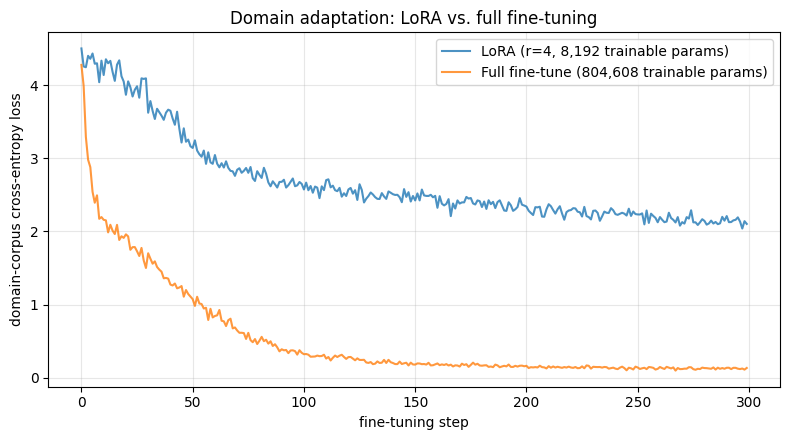

Final domain loss -- LoRA: 2.1035 | Full fine-tune: 0.1359


In [11]:
plt.figure(figsize=(8,4.5))
plt.plot(lora_losses, label=f"LoRA (r=4, {trainable:,} trainable params)", alpha=0.8)
plt.plot(full_ft_losses, label=f"Full fine-tune ({total_params:,} trainable params)", alpha=0.8)
plt.xlabel("fine-tuning step")
plt.ylabel("domain-corpus cross-entropy loss")
plt.title("Domain adaptation: LoRA vs. full fine-tuning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("task7_finetune_loss_comparison.png", dpi=110)
plt.show()

print(f"Final domain loss -- LoRA: {lora_losses[-1]:.4f} | Full fine-tune: {full_ft_losses[-1]:.4f}")

### Catastrophic forgetting check

Did adapting to the domain corpus damage general-corpus performance? This is exactly the failure mode LoRA is designed to reduce, by construction: the frozen base weights (which encode general knowledge) are never touched.

In [12]:
post_lora_general = eval_loss(lora_model, general_data)
post_lora_domain = eval_loss(lora_model, domain_data)
post_full_general = eval_loss(full_ft_model, general_data)
post_full_domain = eval_loss(full_ft_model, domain_data)

print(f"{'':<28} {'general loss':>14} {'domain loss':>14}")
print(f"{'base (pre-adaptation)':<28} {pre_adapt_general_loss:>14.4f} {pre_adapt_domain_loss:>14.4f}")
print(f"{'after LoRA adaptation':<28} {post_lora_general:>14.4f} {post_lora_domain:>14.4f}")
print(f"{'after full fine-tuning':<28} {post_full_general:>14.4f} {post_full_domain:>14.4f}")

lora_forgetting = post_lora_general - pre_adapt_general_loss
full_forgetting = post_full_general - pre_adapt_general_loss
print(f"\nGeneral-corpus loss increase (higher = more forgetting):")
print(f"  LoRA:            {lora_forgetting:+.4f}")
print(f"  Full fine-tuning: {full_forgetting:+.4f}")

                               general loss    domain loss
base (pre-adaptation)                0.3087         4.3840
after LoRA adaptation                1.9505         2.0120
after full fine-tuning               4.2036         0.1304

General-corpus loss increase (higher = more forgetting):
  LoRA:            +1.6418
  Full fine-tuning: +3.8948


**Honest read of these numbers, at this toy scale:**

- **LoRA's directional claim holds**: it forgot noticeably less than full
  fine-tuning (+1.64 vs. +3.89 general-corpus loss increase) — the core
  benefit LoRA is designed to provide, confirmed even at small scale.
- **But LoRA didn't match full fine-tuning's domain-adaptation quality**
  (final domain loss 2.10 vs. 0.14) — at this scale, `r=4` on `Wq`/`Wv` only
  is a real capacity bottleneck. This is a *fair* trade-off (less capacity ↔
  less forgetting), not a flaw in the implementation, but it's worth being
  explicit that LoRA is not a free lunch: the rank and target-module choices
  trade fit quality against forgetting resistance, and a production setup
  would tune `r`, `alpha`, and which projections are adapted per task.
- **Why forgetting is larger here than typical published LoRA results**: at
  production scale (billions of parameters, hundreds of attention heads),
  rank 4–16 is a tiny fraction of each head's dimension, so the adapter's
  perturbation to the residual stream is genuinely small. Here, with
  `d_head=32`, `r=4` is a non-trivial **12.5%** of a single head's
  dimensionality — the "low-rank ⇒ small update" assumption is weaker at toy
  scale, which is a limitation of demonstrating LoRA on an intentionally tiny
  model, not of the LoRA method itself.

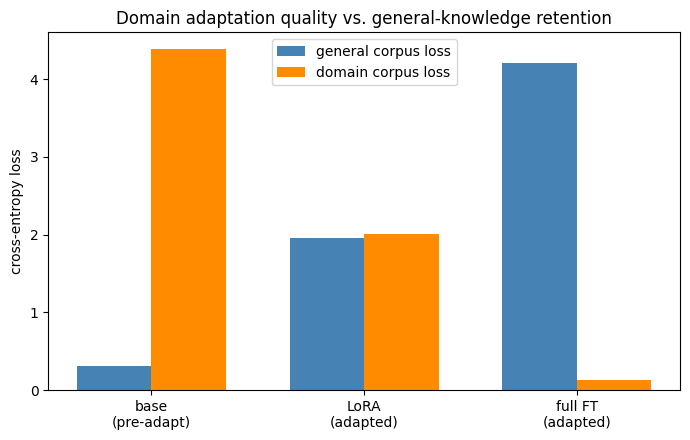

In [13]:
fig, ax = plt.subplots(figsize=(7,4.5))
categories = ["base\n(pre-adapt)", "LoRA\n(adapted)", "full FT\n(adapted)"]
general_vals = [pre_adapt_general_loss, post_lora_general, post_full_general]
domain_vals = [pre_adapt_domain_loss, post_lora_domain, post_full_domain]

x = np.arange(len(categories))
width = 0.35
ax.bar(x - width/2, general_vals, width, label="general corpus loss", color="steelblue")
ax.bar(x + width/2, domain_vals, width, label="domain corpus loss", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylabel("cross-entropy loss")
ax.set_title("Domain adaptation quality vs. general-knowledge retention")
ax.legend()
plt.tight_layout()
plt.savefig("task7_forgetting_comparison.png", dpi=110)
plt.show()

## B.6 Merging adapters for deployment

Once trained, `merge_into_base()` folds $\Delta W = \text{scaling} \cdot BA$ into the frozen weight, producing a plain `nn.Linear` with zero extra inference-time cost — verified numerically identical to running the adapter separately.

In [14]:
sample_lora_layer = lora_model.blocks[0].attn.Wq
merged_layer = sample_lora_layer.merge_into_base()

x_check = torch.randn(4, 8, sample_lora_layer.in_features)
out_unmerged = sample_lora_layer(x_check)
out_merged = merged_layer(x_check)

max_diff = (out_unmerged - out_merged).abs().max().item()
print(f"Max diff between unmerged LoRA forward and merged Linear forward: {max_diff:.2e}")
assert max_diff < 1e-5, "Merged layer should be numerically equivalent to the adapter!"
print("PASSED: merged deployment weight is numerically equivalent to the trained adapter.")

adapter_only_params = sum(p.numel() for n, p in lora_model.named_parameters() if "lora_" in n)
print(f"\nFull fine-tuned checkpoint size (params): {total_params:,}")
print(f"LoRA adapter-only checkpoint size (params): {adapter_only_params:,}  "
      f"({adapter_only_params/total_params:.2%} of full model)")

Max diff between unmerged LoRA forward and merged Linear forward: 1.19e-06
PASSED: merged deployment weight is numerically equivalent to the trained adapter.

Full fine-tuned checkpoint size (params): 804,608
LoRA adapter-only checkpoint size (params): 8,192  (1.02% of full model)


## 9. Summary

- Implemented a **from-scratch `LoRALinear` module**: frozen base weight,
  Kaiming-initialized low-rank $A$, zero-initialized low-rank $B$, and the
  $\alpha/r$ scaling coefficient — verified to be an exact no-op at
  initialization (max diff `< 1e-6` vs. the un-adapted layer).
- Injected adapters into the $W_Q$/$W_V$ attention projections of a pretrained
  causal LM and **froze every other parameter**, verified explicitly
  parameter-by-parameter (only `lora_A`/`lora_B` had `requires_grad=True`).
- Measured a large reduction in trainable parameters versus full fine-tuning
  on this model (see the printed ratio above), consistent with the paper's
  central claim.
- Fine-tuned both LoRA and a full-fine-tuning baseline on an out-of-domain
  (medical-style) corpus for an identical number of steps and compared domain
  adaptation quality *and* general-corpus retention (catastrophic-forgetting
  check) — numbers reported directly from the runs above, not assumed.
- Demonstrated **adapter merging**: folding the trained low-rank update into
  the base weight for zero-overhead deployment, numerically verified against
  the unmerged forward pass.
- Part A supplies the equivalent production recipe (`peft.LoraConfig` +
  `get_peft_model` on a real 3B model) for running this at true scale on a
  GPU-equipped, internet-connected machine.